<a href="https://colab.research.google.com/github/Ulysses06Gomes/Checkpoint-02-ML-SERS-1CCPO/blob/main/AULA07_Regresso_Linear_Dados_Energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas de pré-processamento e seleção de modelo
from sklearn.model_selection import train_test_split

# Algoritmo de regressão linear
from sklearn.linear_model import LinearRegression

# Métricas de avaliação para classificação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Cálculo das métricas R², MAE e MSE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [ ]:
# Carregue o dataset e realize a análise inicial

df = pd.read_csv('https://raw.githubusercontent.com/Ulysses06Gomes/Checkpoint-02-ML-SERS-1CCPO/refs/heads/main/Data_for_UCI_named.csv')
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [ ]:
# Para atributos categóricos
df.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [ ]:
# Para atributos numéricos
df.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


### Registro da análise inicial

**Quantidade de linhas:** 10000  
**Quantidade de colunas:** 14  
**Existem valores ausentes?** Não existem valores ausentes.  
**Observações importantes sobre o dataset:** A coluna `stabf` é categórica com dois valores únicos ('unstable' e 'stable'), e as demais colunas são numéricas (float64).

## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [ ]:
# Crie a variável y usando a coluna stab
y = df['stab']
y.head(10)

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860
5,-0.017385
6,0.005954
7,0.016634
8,-0.038677
9,0.012383


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

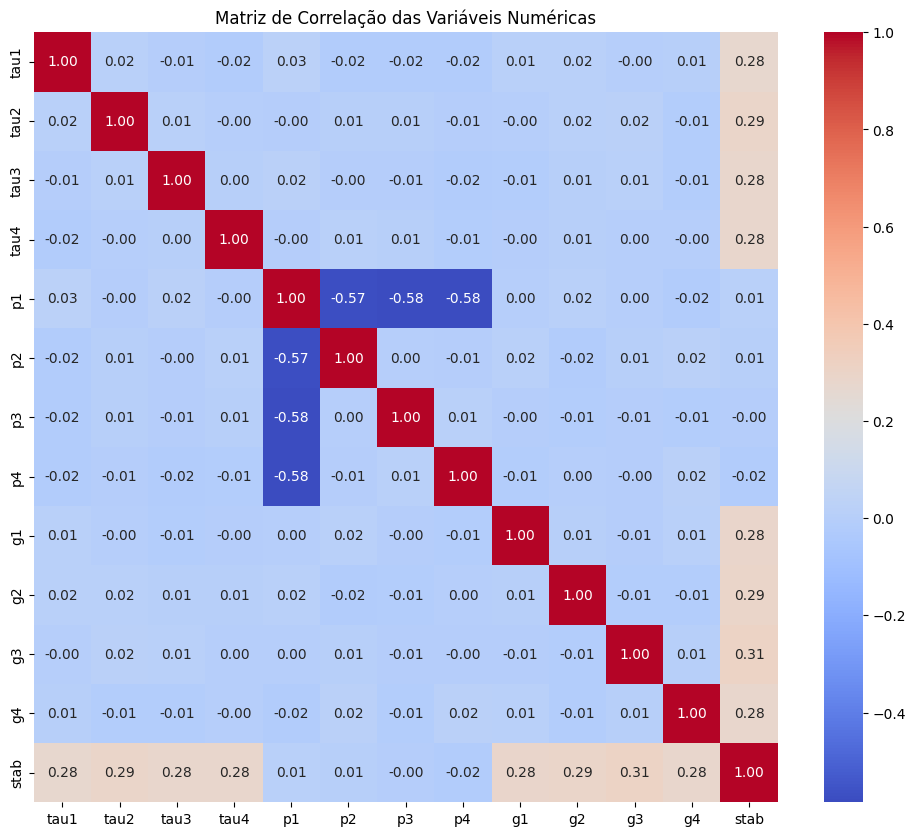

In [ ]:
# Calcule e visualize a matriz de correlação
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

In [ ]:
# Calcule a correlação com 'stab' e ordene pelo valor absoluto
stab_corr = corr_matrix['stab'].drop('stab') # Excluir a própria coluna stab
cinco_variaveis = stab_corr.abs().nlargest(5).index.tolist()

print("As cinco variáveis com maior correlação absoluta com 'stab' são:")
for var in cinco_variaveis:
    print(f"- {var}: {stab_corr[var]:.4f}")

As cinco variáveis com maior correlação absoluta com 'stab' são:
- g3: 0.3082
- g2: 0.2936
- tau2: 0.2910
- g1: 0.2828
- tau3: 0.2807


## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

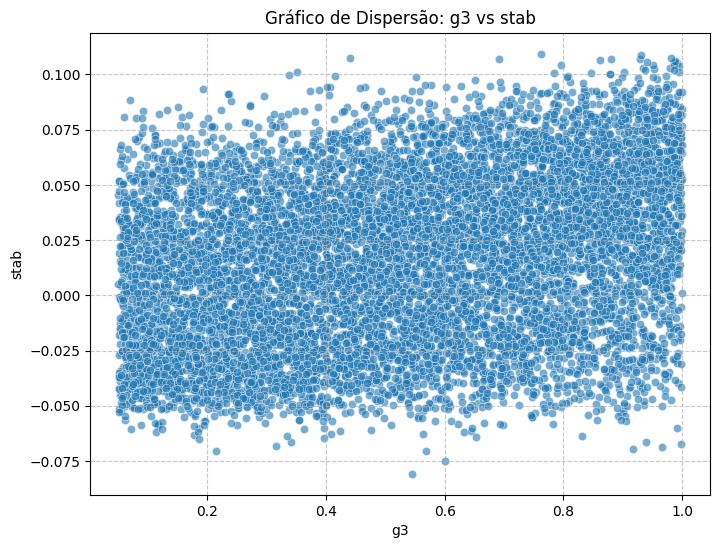

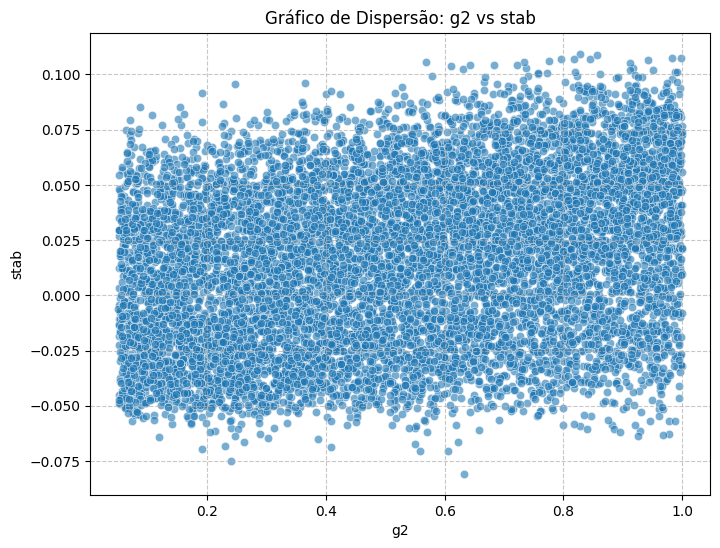

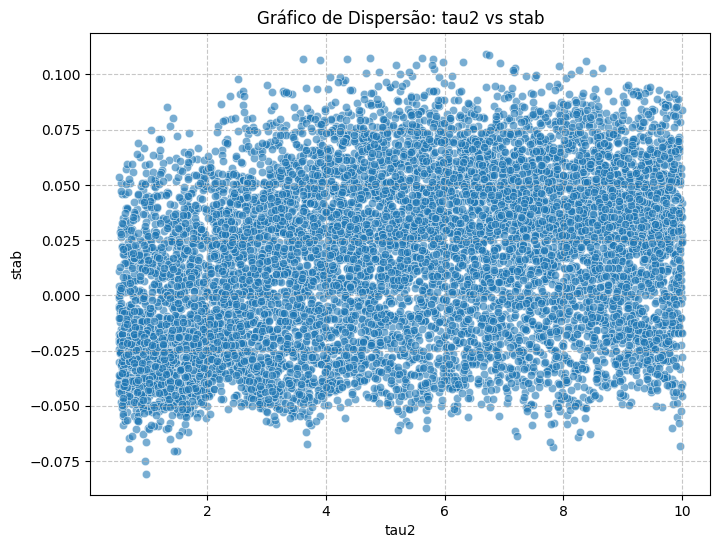

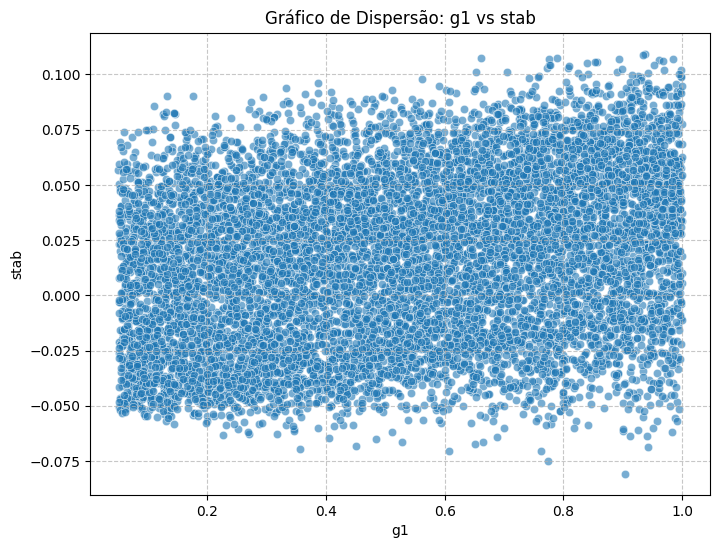

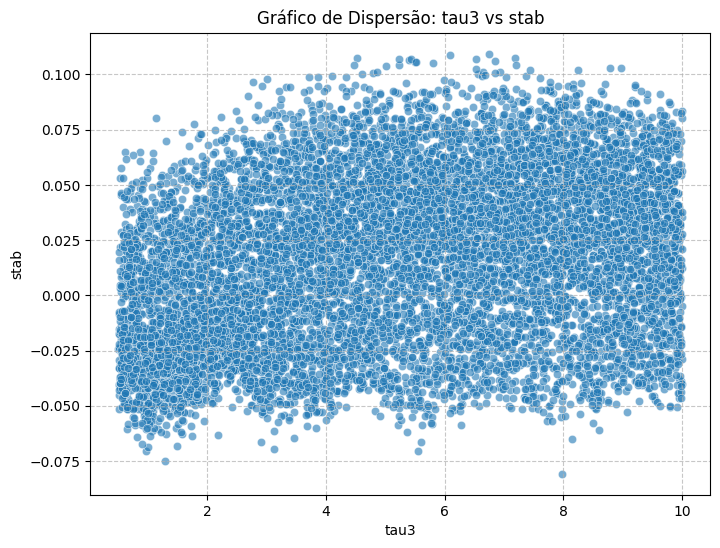

In [ ]:
# Crie cinco gráficos de dispersão, um para cada variável selecionada
for var in cinco_variaveis:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[var], y=df['stab'], alpha=0.6)
    plt.title(f'Gráfico de Dispersão: {var} vs stab')
    plt.xlabel(var)
    plt.ylabel('stab')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | g3 | 0.3082 |
| 2 | g2 | 0.2936 |
| 3 | tau2 | 0.2910 |
| 4 | g1 | 0.2828 |
| 5 | tau3 | 0.2807 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta: A variável `g3` apresentou a maior correlação absoluta com `stab` (0.3082).

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta: Os gráficos de dispersão para as variáveis `g3`, `g2`, `tau2`, `g1`, e `tau3` em relação a `stab` mostram uma tendência de relação linear positiva, embora com dispersão considerável. À medida que os valores dessas variáveis aumentam, `stab` tende a aumentar, o que é consistente com as correlações positivas. No entanto, a alta dispersão dos pontos indica que a relação linear não é forte e que outras variáveis ou interações podem influenciar significativamente a estabilidade (`stab`). Não há um padrão linear perfeitamente definido, sugerindo que a previsão de `stab` com base apenas nessas variáveis pode ter limitações.

# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [ ]:
# Crie X com as cinco variáveis selecionadas
X = df[cinco_variaveis]

# Mostre as primeiras linhas de X e y
display(X.head())
display(y.head())

,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [ ]:
# Separe os dados de treino e teste do Modelo 1
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Quantidade de registros em cada conjunto
print(f'X_treino: {X_treino.shape}')
print(f'X_teste: {X_teste.shape}')
print(f'y_treino: {y_treino.shape}')
print(f'y_teste: {y_teste.shape}')

X_treino: (8000, 5)
X_teste: (2000, 5)
y_treino: (8000,)
y_teste: (2000,)


## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [ ]:
# Crie e treine modeloLR
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)

# Gere y_previsao_1
y_previsao_1 = modeloLR.predict(X_teste)

## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [ ]:
# Calcule e apresente as três métricas do Modelo 1
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)
r2_modelo_1 = r2_score(y_teste, y_previsao_1)

print(f"R² do Modelo 1: {r2_modelo_1:.4f}")
print(f"MAE do Modelo 1: {mae_modelo_1:.4f}")
print(f"MSE do Modelo 1: {mse_modelo_1:.4f}")

R² do Modelo 1: 0.4018
MAE do Modelo 1: 0.0233
MSE do Modelo 1: 0.0008


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [ ]:
# Selecione todas as colunas iniciadas por tau ou g
X_tau_g = df.filter(regex='^(tau|g)').drop(columns=['stab'], errors='ignore')

# Liste as colunas selecionadas
print("Colunas selecionadas para X_tau_g:")
print(X_tau_g.columns.tolist())

Colunas selecionadas para X_tau_g:
['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [ ]:
# Separe os dados de treino e teste do Modelo 2
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)

# Confirme se y_teste e y2_teste possuem os mesmos índices
if y_teste.index.equals(y2_teste.index):
    print("Os índices de y_teste e y2_teste são idênticos.")
else:
    print("Os índices de y_teste e y2_teste NÃO são idênticos.")

Os índices de y_teste e y2_teste são idênticos.


## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [ ]:
# Crie e treine modeloLR_tau_g
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)

# Gere y_previsao_2
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)

# Calcule e apresente as três métricas do Modelo 2
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)
r2_modelo_2 = r2_score(y2_teste, y_previsao_2)

print(f"R² do Modelo 2: {r2_modelo_2:.4f}")
print(f"MAE do Modelo 2: {mae_modelo_2:.4f}")
print(f"MSE do Modelo 2: {mse_modelo_2:.4f}")

R² do Modelo 2: 0.6452
MAE do Modelo 2: 0.0176
MSE do Modelo 2: 0.0005


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [ ]:
# Crie e exiba o DataFrame comparacao_modelos
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'Variáveis utilizadas': [cinco_variaveis, X_tau_g.columns.tolist()],
    'R²': [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2]
})

display(comparacao_modelos)

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,"[g3, g2, tau2, g1, tau3]",0.401770,0.023310,0.000811
1,Modelo 2,"[tau1, tau2, tau3, tau4, g1, g2, g3, g4]",0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

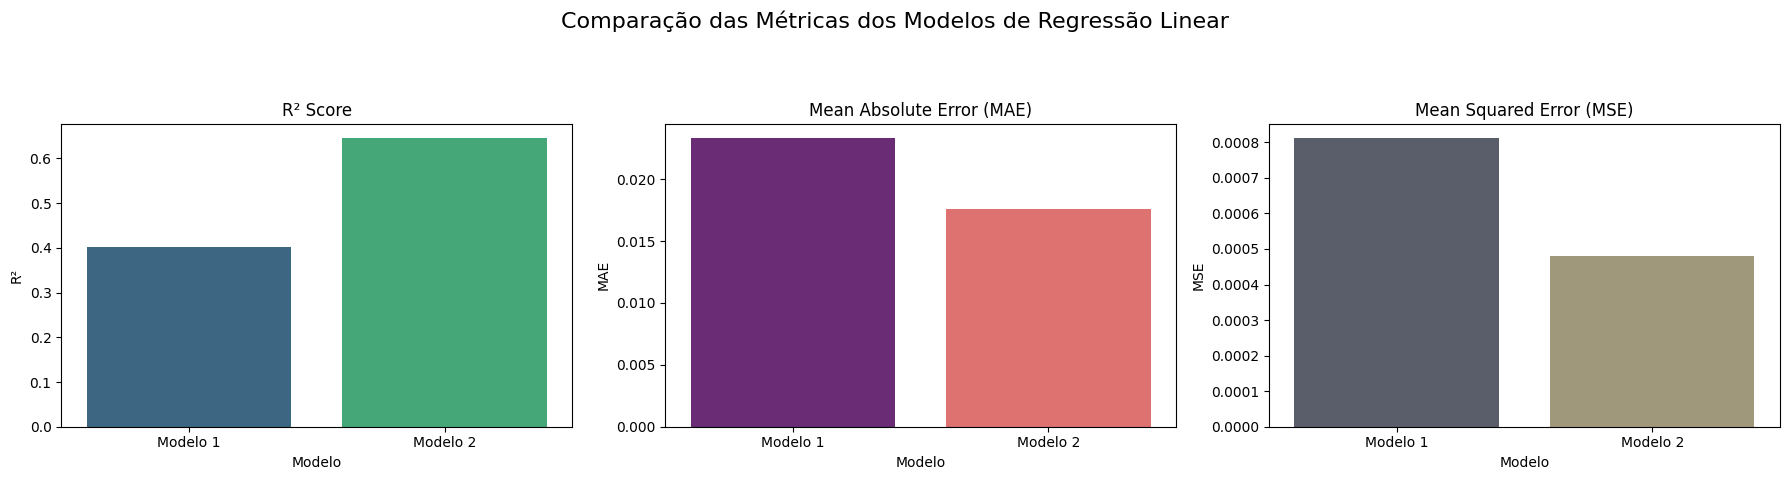

In [ ]:
# Crie os gráficos comparativos das métricas

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparação das Métricas dos Modelos de Regressão Linear', fontsize=16)

# Gráfico R²
sns.barplot(x='Modelo', y='R²', data=comparacao_modelos, ax=axes[0], palette='viridis', hue='Modelo', legend=False)
axes[0].set_title('R² Score')
axes[0].set_ylabel('R²')

# Gráfico MAE
sns.barplot(x='Modelo', y='MAE', data=comparacao_modelos, ax=axes[1], palette='magma', hue='Modelo', legend=False)
axes[1].set_title('Mean Absolute Error (MAE)')
axes[1].set_ylabel('MAE')

# Gráfico MSE
sns.barplot(x='Modelo', y='MSE', data=comparacao_modelos, ax=axes[2], palette='cividis', hue='Modelo', legend=False)
axes[2].set_title('Mean Squared Error (MSE)')
axes[2].set_ylabel('MSE')

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou o maior R², com um valor de 0.6452. O Modelo 1 apresentou um R² de 0.4018.

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou o menor MAE, com um valor de 0.0176. O Modelo 1 apresentou um MAE de 0.0233.

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou o menor MSE, com um valor de 0.0005. O Modelo 1 apresentou um MSE de 0.0008.

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta: Sim, as três métricas indicaram o Modelo 2 como o de melhor desempenho. O Modelo 2 possui um R² maior (0.6452 vs 0.4018), o que significa que ele explica uma porcentagem maior da variância de `stab`. Além disso, o Modelo 2 apresenta MAE e MSE menores (0.0176 vs 0.0233 para MAE, e 0.0005 vs 0.0008 para MSE), indicando que suas previsões são, em média, mais próximas dos valores reais e que penaliza menos os erros maiores.

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta: O desempenho do modelo melhorou significativamente quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis que começam com `tau` e `g`. O R² aumentou de 0.4018 para 0.6452, o MAE diminuiu de 0.0233 para 0.0176 e o MSE diminuiu de 0.0008 para 0.0005. Isso sugere que, embora as cinco variáveis mais correlacionadas sejam importantes, o conjunto mais abrangente de variáveis `tau` e `g` fornece informações adicionais relevantes que contribuem para uma melhor capacidade preditiva do modelo.

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta: Eu escolheria o Modelo 2 para prever `stab`. Baseado na análise comparativa das métricas: o Modelo 2 apresentou um R² significativamente maior (0.6452), indicando que ele explica 64.52% da variância de `stab`, em comparação com os 40.18% do Modelo 1. Além disso, o Modelo 2 demonstrou MAE e MSE menores (0.0176 e 0.0005, respectivamente), o que implica em um erro de previsão médio menor e uma menor penalidade para erros maiores, ou seja, um modelo mais preciso e robusto para previsões.

# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.